## Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Generate Semi-Structured JSON Data 

In [2]:
# Simulate realistic market JSON data (as would come from a financial API)
np.random.seed(42)
n_days = 500
start_date = datetime(2022, 1, 1)

companies = [
    {"ticker": "RELIANCE", "sector": "Energy",      "market_cap": "Large"},
    {"ticker": "TCS",      "sector": "IT",           "market_cap": "Large"},
    {"ticker": "HDFC",     "sector": "Finance",      "market_cap": "Large"},
    {"ticker": "INFY",     "sector": "IT",           "market_cap": "Large"},
    {"ticker": "WIPRO",    "sector": "IT",           "market_cap": "Mid"},
    {"ticker": "SBIN",     "sector": "Finance",      "market_cap": "Large"},
    {"ticker": "TATASTEEL","sector": "Manufacturing","market_cap": "Mid"},
    {"ticker": "BAJFINANCE","sector":"Finance",      "market_cap": "Large"},
]

market_json = []

for company in companies:
    price = np.random.uniform(500, 3000)
    for i in range(n_days):
        date = start_date + timedelta(days=i)
        if date.weekday() >= 5:   # skip weekends
            continue
        daily_return = np.random.normal(0.0003, 0.018)
        price = price * (1 + daily_return)
        volume = int(np.random.uniform(500000, 5000000))
        record = {
            "date": date.strftime("%Y-%m-%d"),
            "ticker": company["ticker"],
            "company_info": {
                "sector": company["sector"],
                "market_cap_category": company["market_cap"]
            },
            "ohlcv": {
                "open":   round(price * np.random.uniform(0.99, 1.01), 2),
                "high":   round(price * np.random.uniform(1.00, 1.03), 2),
                "low":    round(price * np.random.uniform(0.97, 1.00), 2),
                "close":  round(price, 2),
                "volume": volume
            },
            "risk_metrics": {
                "beta":              round(np.random.uniform(0.5, 1.8), 3),
                "volatility_30d":    round(abs(np.random.normal(0.02, 0.008)), 4),
                "rsi":               round(np.random.uniform(25, 75), 2),
                "sentiment_score":   round(np.random.uniform(-1, 1), 3)
            },
            "macro": {
                "interest_rate":  round(np.random.uniform(4.5, 7.5), 2),
                "inflation_rate": round(np.random.uniform(3.0, 8.0), 2),
                "vix":            round(np.random.uniform(10, 40), 2)
            }
        }
        market_json.append(record)

# Save as JSON file
with open("market_data.json", "w") as f:
    json.dump(market_json, f, indent=2)

print(f"✅ JSON dataset created: {len(market_json)} records")
print(f"\nSample record (raw JSON):")
print(json.dumps(market_json[0], indent=2))

✅ JSON dataset created: 2848 records

Sample record (raw JSON):
{
  "date": "2022-01-03",
  "ticker": "RELIANCE",
  "company_info": {
    "sector": "Energy",
    "market_cap_category": "Large"
  },
  "ohlcv": {
    "open": 1395.59,
    "high": 1444.62,
    "low": 1391.19,
    "close": 1408.03,
    "volume": 1201975
  },
  "risk_metrics": {
    "beta": 1.42,
    "volatility_30d": 0.0226,
    "rsi": 26.03,
    "sentiment_score": 0.94
  },
  "macro": {
    "interest_rate": 7.0,
    "inflation_rate": 4.06,
    "vix": 15.45
  }
}


## Load JSON & Inspect Raw Structure


In [3]:
print("=" * 55)
print("STEP 1 — LOAD JSON DATA")
print("=" * 55)

# Load JSON
with open("market_data.json", "r") as f:
    raw_data = json.load(f)

print(f"Total records loaded : {len(raw_data)}")
print(f"Type                 : {type(raw_data)}")
print(f"Keys in one record   : {list(raw_data[0].keys())}")
print(f"\nNested keys:")
for key, val in raw_data[0].items():
    if isinstance(val, dict):
        print(f"  {key} → {list(val.keys())}")
    else:
        print(f"  {key} → {val}")

STEP 1 — LOAD JSON DATA
Total records loaded : 2848
Type                 : <class 'list'>
Keys in one record   : ['date', 'ticker', 'company_info', 'ohlcv', 'risk_metrics', 'macro']

Nested keys:
  date → 2022-01-03
  ticker → RELIANCE
  company_info → ['sector', 'market_cap_category']
  ohlcv → ['open', 'high', 'low', 'close', 'volume']
  risk_metrics → ['beta', 'volatility_30d', 'rsi', 'sentiment_score']
  macro → ['interest_rate', 'inflation_rate', 'vix']


## Data Shredding: JSON → Multiple Structured DataFrames


In [4]:
print("=" * 55)
print("STEP 2 — DATA SHREDDING (JSON → DataFrames)")
print("=" * 55)

# ── DataFrame 1: Core Price Data ──────────────────────────────────────────────
df_prices = pd.DataFrame([{
    "date":    r["date"],
    "ticker":  r["ticker"],
    "open":    r["ohlcv"]["open"],
    "high":    r["ohlcv"]["high"],
    "low":     r["ohlcv"]["low"],
    "close":   r["ohlcv"]["close"],
    "volume":  r["ohlcv"]["volume"]
} for r in raw_data])
df_prices["date"] = pd.to_datetime(df_prices["date"])
df_prices = df_prices.sort_values(["ticker", "date"]).reset_index(drop=True)

# ── DataFrame 2: Risk Metrics ─────────────────────────────────────────────────
df_risk = pd.DataFrame([{
    "date":             r["date"],
    "ticker":           r["ticker"],
    "beta":             r["risk_metrics"]["beta"],
    "volatility_30d":   r["risk_metrics"]["volatility_30d"],
    "rsi":              r["risk_metrics"]["rsi"],
    "sentiment_score":  r["risk_metrics"]["sentiment_score"]
} for r in raw_data])
df_risk["date"] = pd.to_datetime(df_risk["date"])

# ── DataFrame 3: Macro Economic Data ─────────────────────────────────────────
df_macro = pd.DataFrame([{
    "date":             r["date"],
    "ticker":           r["ticker"],
    "interest_rate":    r["macro"]["interest_rate"],
    "inflation_rate":   r["macro"]["inflation_rate"],
    "vix":              r["macro"]["vix"]
} for r in raw_data])
df_macro["date"] = pd.to_datetime(df_macro["date"])

# ── DataFrame 4: Company Info ─────────────────────────────────────────────────
df_company = pd.DataFrame([{
    "ticker":              r["ticker"],
    "sector":              r["company_info"]["sector"],
    "market_cap_category": r["company_info"]["market_cap_category"]
} for r in raw_data]).drop_duplicates(subset="ticker").reset_index(drop=True)

print(f"✅ df_prices   : {df_prices.shape}   — OHLCV price data")
print(f"✅ df_risk     : {df_risk.shape}   — Beta, Volatility, RSI, Sentiment")
print(f"✅ df_macro    : {df_macro.shape}   — Interest rate, Inflation, VIX")
print(f"✅ df_company  : {df_company.shape}    — Sector, Market cap category")

print(f"\n--- df_prices (head) ---\n{df_prices.head()}")
print(f"\n--- df_risk (head) ---\n{df_risk.head()}")
print(f"\n--- df_macro (head) ---\n{df_macro.head()}")
print(f"\n--- df_company ---\n{df_company}")

STEP 2 — DATA SHREDDING (JSON → DataFrames)
✅ df_prices   : (2848, 7)   — OHLCV price data
✅ df_risk     : (2848, 6)   — Beta, Volatility, RSI, Sentiment
✅ df_macro    : (2848, 5)   — Interest rate, Inflation, VIX
✅ df_company  : (8, 3)    — Sector, Market cap category

--- df_prices (head) ---
        date      ticker    open    high     low   close   volume
0 2022-01-03  BAJFINANCE  919.49  935.50  907.57  916.46  1115569
1 2022-01-04  BAJFINANCE  880.23  907.70  885.42  885.43  2858114
2 2022-01-05  BAJFINANCE  899.58  900.83  891.20  895.27  3671791
3 2022-01-06  BAJFINANCE  877.16  886.58  865.19  870.51  1011582
4 2022-01-07  BAJFINANCE  849.72  861.99  839.29  845.75  4753365

--- df_risk (head) ---
        date    ticker   beta  volatility_30d    rsi  sentiment_score
0 2022-01-03  RELIANCE  1.420          0.0226  26.03            0.940
1 2022-01-04  RELIANCE  0.681          0.0126  39.61           -0.267
2 2022-01-05  RELIANCE  1.734          0.0232  73.28            0.617
3 20

## Transform & Merge into Master DataFrame


In [5]:
print("=" * 55)
print("STEP 3 — TRANSFORM & MERGE DATAFRAMES")
print("=" * 55)

# ── Merge all shards on date + ticker ────────────────────────────────────────
df_master = df_prices \
    .merge(df_risk,    on=["date", "ticker"], how="left") \
    .merge(df_macro,   on=["date", "ticker"], how="left") \
    .merge(df_company, on="ticker",           how="left")

# ── Feature Engineering ───────────────────────────────────────────────────────
df_master = df_master.sort_values(["ticker", "date"]).reset_index(drop=True)

# Daily return
df_master["daily_return"] = df_master.groupby("ticker")["close"].pct_change()

# Price range
df_master["price_range"] = df_master["high"] - df_master["low"]
df_master["price_range_pct"] = df_master["price_range"] / df_master["close"] * 100

# Rolling features per ticker
df_master["ma_7"]      = df_master.groupby("ticker")["close"].transform(lambda x: x.rolling(7).mean())
df_master["ma_30"]     = df_master.groupby("ticker")["close"].transform(lambda x: x.rolling(30).mean())
df_master["vol_7d"]    = df_master.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(7).std())
df_master["vol_30d"]   = df_master.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(30).std())

# Risk label: High risk if volatility > 75th percentile
vol_threshold = df_master["vol_30d"].quantile(0.75)
df_master["risk_label"] = (df_master["vol_30d"] > vol_threshold).astype(int)
df_master["risk_category"] = df_master["risk_label"].map({0: "Low Risk", 1: "High Risk"})

# Encode sector
df_master["sector_encoded"] = pd.factorize(df_master["sector"])[0]

df_master.dropna(inplace=True)
df_master.reset_index(drop=True, inplace=True)

print(f"Master DataFrame shape : {df_master.shape}")
print(f"Columns                : {df_master.columns.tolist()}")
print(f"\nRisk Label Distribution:\n{df_master['risk_category'].value_counts()}")
print(f"\nSample:\n{df_master.head()}")

STEP 3 — TRANSFORM & MERGE DATAFRAMES
Master DataFrame shape : (2608, 26)
Columns                : ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'beta', 'volatility_30d', 'rsi', 'sentiment_score', 'interest_rate', 'inflation_rate', 'vix', 'sector', 'market_cap_category', 'daily_return', 'price_range', 'price_range_pct', 'ma_7', 'ma_30', 'vol_7d', 'vol_30d', 'risk_label', 'risk_category', 'sector_encoded']

Risk Label Distribution:
risk_category
Low Risk     1956
High Risk     652
Name: count, dtype: int64

Sample:
        date      ticker    open    high     low   close   volume   beta  \
0 2022-02-14  BAJFINANCE  816.50  810.06  790.16  809.74  1970581  1.049   
1 2022-02-15  BAJFINANCE  834.93  836.22  812.24  835.79  3362532  0.655   
2 2022-02-16  BAJFINANCE  839.26  845.08  831.60  831.72  2800992  0.685   
3 2022-02-17  BAJFINANCE  842.34  844.15  820.35  839.32  1134543  1.513   
4 2022-02-18  BAJFINANCE  844.37  853.74  837.14  846.18  1701918  0.632   

   volat

## Statistical Summary & EDA


STEP 4 — EDA & STATISTICAL SUMMARY
           close  daily_return       beta  volatility_30d        rsi  \
count  2608.0000     2608.0000  2608.0000       2608.0000  2608.0000   
mean   1835.5977       -0.0001     1.1471          0.0198    50.2821   
std     851.3219        0.0181     0.3732          0.0080    14.4859   
min     634.1200       -0.0691     0.5000          0.0000    25.0300   
25%    1195.4100       -0.0125     0.8310          0.0143    38.1075   
50%    1718.4550       -0.0004     1.1460          0.0198    50.1150   
75%    2156.9775        0.0124     1.4670          0.0252    63.1225   
max    4288.8300        0.0567     1.8000          0.0515    74.9900   

             vix    vol_30d  
count  2608.0000  2608.0000  
mean     25.2100     0.0180  
std       8.7423     0.0026  
min      10.0100     0.0098  
25%      17.3775     0.0163  
50%      25.1800     0.0181  
75%      32.9100     0.0195  
max      39.9800     0.0261  


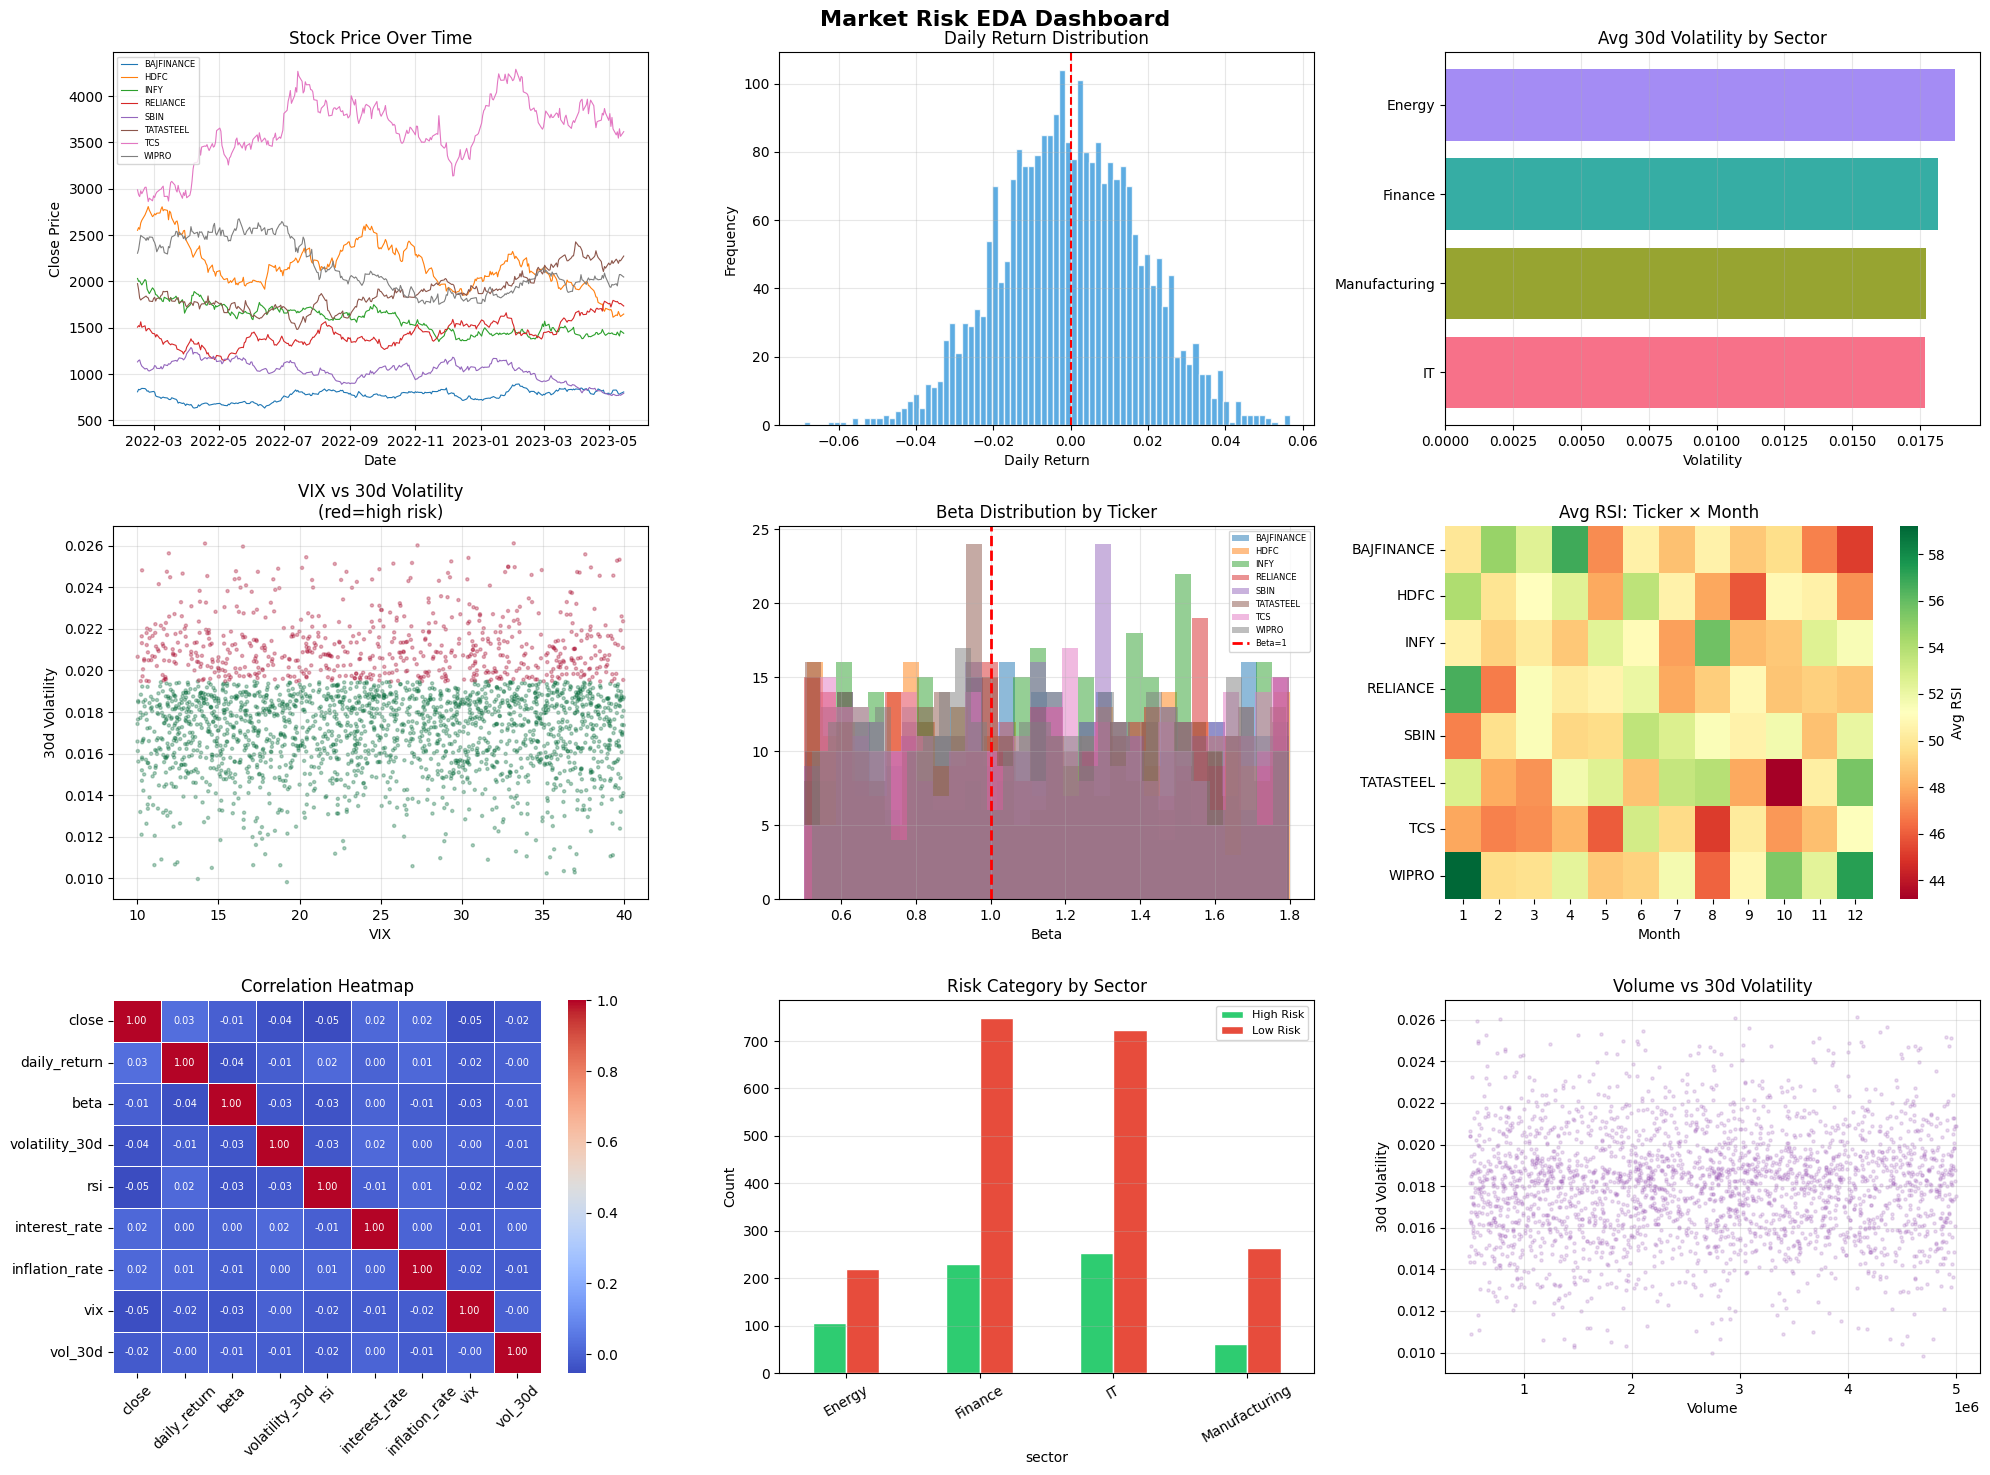

In [6]:
print("=" * 55)
print("STEP 4 — EDA & STATISTICAL SUMMARY")
print("=" * 55)

print(df_master[["close","daily_return","beta","volatility_30d",
                  "rsi","vix","vol_30d"]].describe().round(4))

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Market Risk EDA Dashboard", fontweight='bold', fontsize=16)

# 1. Close price over time per ticker
ax = axes[0, 0]
for ticker in df_master["ticker"].unique():
    sub = df_master[df_master["ticker"] == ticker]
    ax.plot(sub["date"], sub["close"], linewidth=0.8, label=ticker)
ax.set_title("Stock Price Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Close Price")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# 2. Daily Return Distribution
ax = axes[0, 1]
ax.hist(df_master["daily_return"].dropna(), bins=80,
        color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title("Daily Return Distribution")
ax.set_xlabel("Daily Return"); ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

# 3. Volatility by Sector
ax = axes[0, 2]
sector_vol = df_master.groupby("sector")["vol_30d"].mean().sort_values()
ax.barh(sector_vol.index, sector_vol.values,
        color=sns.color_palette("husl", len(sector_vol)))
ax.set_title("Avg 30d Volatility by Sector")
ax.set_xlabel("Volatility"); ax.grid(alpha=0.3, axis='x')

# 4. VIX vs Volatility Scatter
ax = axes[1, 0]
scatter = ax.scatter(df_master["vix"], df_master["vol_30d"],
                     c=df_master["risk_label"], cmap='RdYlGn_r',
                     alpha=0.3, s=5)
ax.set_title("VIX vs 30d Volatility\n(red=high risk)")
ax.set_xlabel("VIX"); ax.set_ylabel("30d Volatility")
ax.grid(alpha=0.3)

# 5. Beta Distribution
ax = axes[1, 1]
for ticker in df_master["ticker"].unique():
    sub = df_master[df_master["ticker"] == ticker]["beta"]
    ax.hist(sub, bins=30, alpha=0.5, label=ticker)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Beta=1')
ax.set_title("Beta Distribution by Ticker")
ax.set_xlabel("Beta"); ax.legend(fontsize=6); ax.grid(alpha=0.3)

# 6. RSI Heatmap by Ticker
ax = axes[1, 2]
pivot_rsi = df_master.groupby(["ticker", df_master["date"].dt.month])["rsi"].mean().unstack()
sns.heatmap(pivot_rsi, ax=ax, cmap="RdYlGn", annot=False,
            cbar_kws={"label": "Avg RSI"})
ax.set_title("Avg RSI: Ticker × Month")
ax.set_xlabel("Month"); ax.set_ylabel("")

# 7. Correlation Heatmap
ax = axes[2, 0]
corr_cols = ["close","daily_return","beta","volatility_30d",
             "rsi","interest_rate","inflation_rate","vix","vol_30d"]
corr = df_master[corr_cols].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap")
ax.tick_params(axis='x', rotation=45)

# 8. Risk Category by Sector
ax = axes[2, 1]
risk_sector = df_master.groupby(["sector","risk_category"]).size().unstack(fill_value=0)
risk_sector.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax.set_title("Risk Category by Sector")
ax.set_ylabel("Count"); ax.set_xticklabels(risk_sector.index, rotation=30)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# 9. Volume vs Volatility
ax = axes[2, 2]
ax.scatter(df_master["volume"], df_master["vol_30d"],
           alpha=0.2, s=5, color='#9b59b6')
ax.set_title("Volume vs 30d Volatility")
ax.set_xlabel("Volume"); ax.set_ylabel("30d Volatility")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

## Time Series Forecasting 


STEP 5 — TIME SERIES FORECASTING
Time series length: 326 trading days

ADF Test — avg_volatility:
  ADF Statistic : -3.6240
  p-value       : 0.0053
  Stationary    : ✅ Yes

ADF Test — avg_vix:
  ADF Statistic : -19.1556
  p-value       : 0.0000
  Stationary    : ✅ Yes


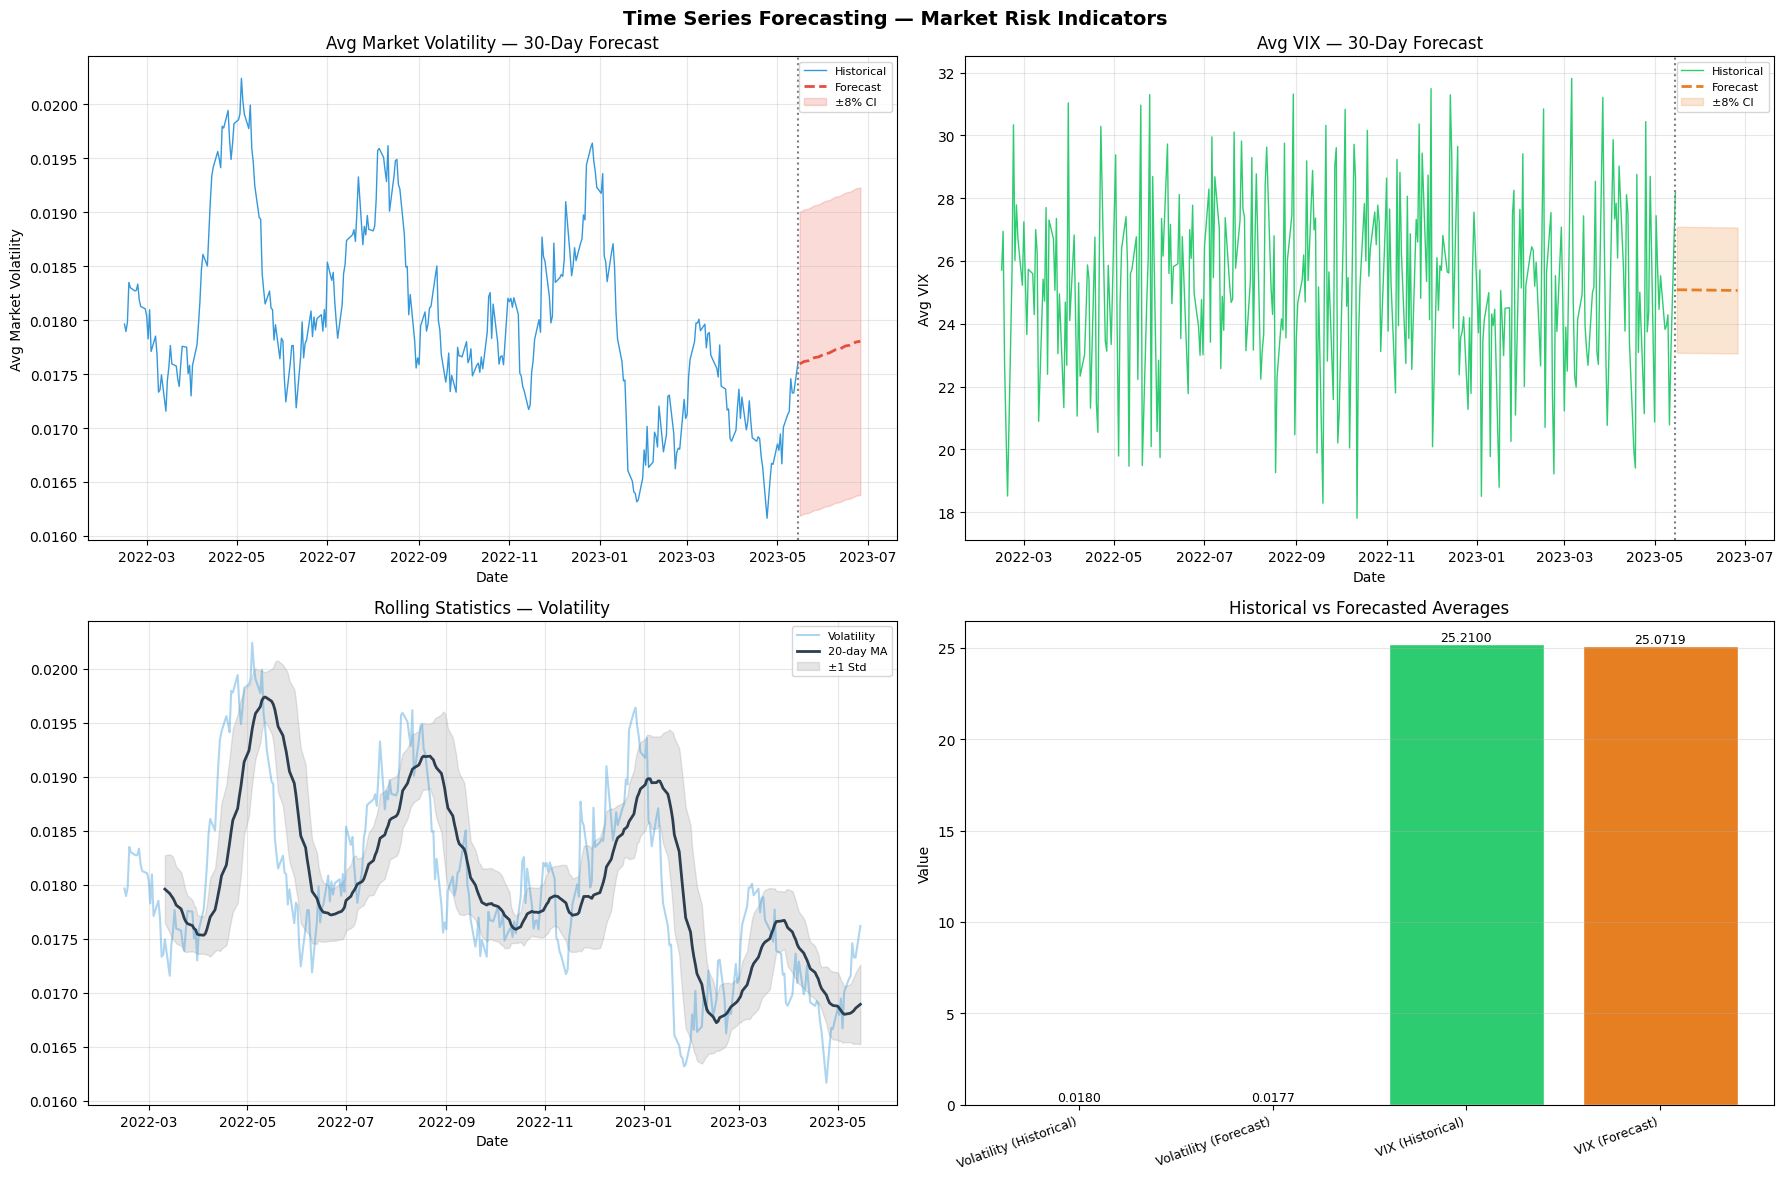

In [7]:
print("=" * 55)
print("STEP 5 — TIME SERIES FORECASTING")
print("=" * 55)

# Aggregate daily market-wide volatility and VIX
ts_df = df_master.groupby("date").agg(
    avg_volatility=("vol_30d", "mean"),
    avg_vix=("vix", "mean"),
    avg_return=("daily_return", "mean")
).reset_index().sort_values("date")

print(f"Time series length: {len(ts_df)} trading days")

# ADF Stationarity Test
for col in ["avg_volatility", "avg_vix"]:
    result = adfuller(ts_df[col].dropna())
    print(f"\nADF Test — {col}:")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Stationary    : {'✅ Yes' if result[1] < 0.05 else '❌ No'}")

# ── Holt-Winters Forecast ─────────────────────────────────────────────────────
forecast_steps = 30
train_vol = ts_df["avg_volatility"].dropna()
train_vix = ts_df["avg_vix"].dropna()

model_vol = ExponentialSmoothing(train_vol, trend='add',
                                  initialization_method='estimated').fit()
model_vix = ExponentialSmoothing(train_vix, trend='add',
                                  initialization_method='estimated').fit()

forecast_vol = model_vol.forecast(forecast_steps)
forecast_vix = model_vix.forecast(forecast_steps)

last_date = ts_df["date"].max()
future_dates = pd.date_range(last_date + timedelta(days=1),
                              periods=forecast_steps, freq='B')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Time Series Forecasting — Market Risk Indicators",
             fontweight='bold', fontsize=14)

for ax, series, forecast, label, color, fc_color in [
    (axes[0,0], train_vol, forecast_vol, "Avg Market Volatility", "#3498db", "#e74c3c"),
    (axes[0,1], train_vix, forecast_vix, "Avg VIX",               "#2ecc71", "#e67e22"),
]:
    ax.plot(ts_df["date"][:len(series)], series,
            color=color, linewidth=1, label="Historical")
    ax.plot(future_dates, forecast,
            color=fc_color, linewidth=2, linestyle='--', label="Forecast")
    ax.fill_between(future_dates, forecast * 0.92, forecast * 1.08,
                    alpha=0.2, color=fc_color, label="±8% CI")
    ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f"{label} — 30-Day Forecast")
    ax.set_xlabel("Date"); ax.set_ylabel(label)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Rolling mean & std — Volatility
ax = axes[1, 0]
roll_mean = train_vol.rolling(20).mean()
roll_std  = train_vol.rolling(20).std()
ax.plot(ts_df["date"], train_vol, alpha=0.4, color='#3498db', label='Volatility')
ax.plot(ts_df["date"], roll_mean, color='#2c3e50', linewidth=2, label='20-day MA')
ax.fill_between(ts_df["date"],
                roll_mean - roll_std, roll_mean + roll_std,
                alpha=0.2, color='gray', label='±1 Std')
ax.set_title("Rolling Statistics — Volatility")
ax.set_xlabel("Date"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Forecast summary bar
ax = axes[1, 1]
forecast_summary = pd.DataFrame({
    "Metric":   ["Volatility (Historical)", "Volatility (Forecast)",
                 "VIX (Historical)",        "VIX (Forecast)"],
    "Value":    [train_vol.mean(), forecast_vol.mean(),
                 train_vix.mean(), forecast_vix.mean()],
    "Color":    ["#3498db","#e74c3c","#2ecc71","#e67e22"]
})
bars = ax.bar(forecast_summary["Metric"], forecast_summary["Value"],
              color=forecast_summary["Color"], edgecolor='white')
for bar, val in zip(bars, forecast_summary["Value"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=9)
ax.set_title("Historical vs Forecasted Averages")
ax.set_xticklabels(forecast_summary["Metric"], rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Value"); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("forecast.png", dpi=150, bbox_inches='tight')
plt.show()

## Risk Prediction Model


In [8]:
print("=" * 55)
print("STEP 6 — MARKET RISK PREDICTION MODEL")
print("=" * 55)

feature_cols = ["beta","volatility_30d","rsi","sentiment_score",
                "interest_rate","inflation_rate","vix",
                "price_range_pct","vol_7d","sector_encoded"]
target_col = "vol_30d"   # Predict next-period volatility (continuous risk score)

df_model = df_master[feature_cols + [target_col]].dropna()

X = df_model[feature_cols]
y = df_model[target_col]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# ── Three models ──────────────────────────────────────────────────────────────
models = {
    "Linear Regression":       LinearRegression(),
    "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":       GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "RMSE":   np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":    mean_absolute_error(y_test, y_pred),
        "R2":     r2_score(y_test, y_pred)
    }
    print(f"\n{name}:")
    print(f"  R²   : {results[name]['R2']:.4f}")
    print(f"  RMSE : {results[name]['RMSE']:.6f}")
    print(f"  MAE  : {results[name]['MAE']:.6f}")

best_model_name = max(results, key=lambda k: results[k]["R2"])
print(f"\n🏆 Best Model: {best_model_name} (R²={results[best_model_name]['R2']:.4f})")

STEP 6 — MARKET RISK PREDICTION MODEL

Linear Regression:
  R²   : 0.1894
  RMSE : 0.002263
  MAE  : 0.001741

Random Forest:
  R²   : 0.1691
  RMSE : 0.002291
  MAE  : 0.001799

Gradient Boosting:
  R²   : 0.1774
  RMSE : 0.002280
  MAE  : 0.001767

🏆 Best Model: Linear Regression (R²=0.1894)


## Model Visualizations


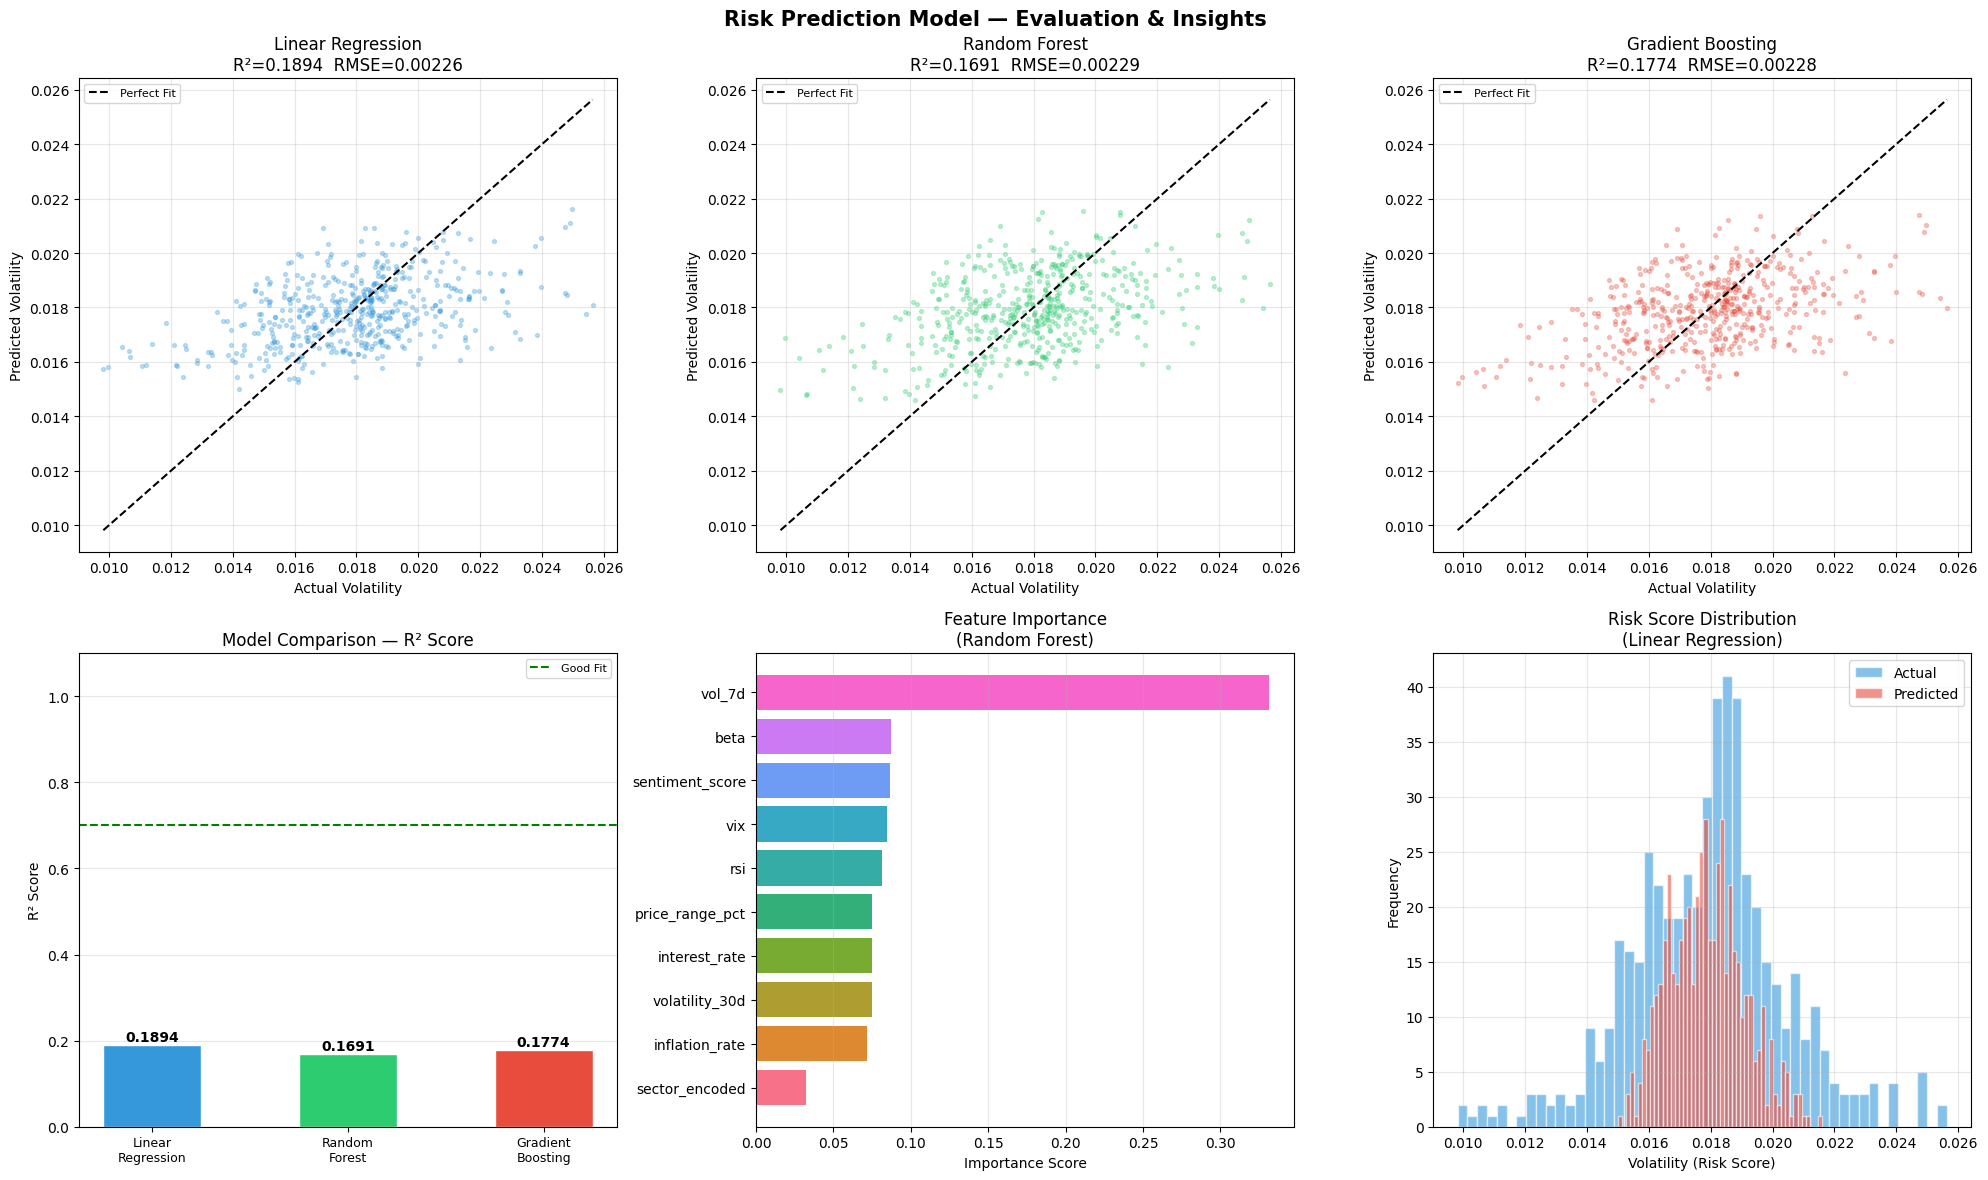

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Risk Prediction Model — Evaluation & Insights",
             fontweight='bold', fontsize=15)

model_names = list(results.keys())
colors_map  = ["#3498db", "#2ecc71", "#e74c3c"]

# 1-3: Actual vs Predicted per model
for i, (name, res) in enumerate(results.items()):
    ax = axes[0, i]
    ax.scatter(y_test, res["y_pred"], alpha=0.3, s=8, color=colors_map[i])
    mn = min(y_test.min(), res["y_pred"].min())
    mx = max(y_test.max(), res["y_pred"].max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f"{name}\nR²={res['R2']:.4f}  RMSE={res['RMSE']:.5f}")
    ax.set_xlabel("Actual Volatility")
    ax.set_ylabel("Predicted Volatility")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4: Model comparison bar
ax = axes[1, 0]
r2_scores = [results[n]["R2"]   for n in model_names]
rmse_scores= [results[n]["RMSE"] for n in model_names]
x_pos = np.arange(len(model_names))
bars = ax.bar(x_pos, r2_scores, color=colors_map, edgecolor='white', width=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(" ","\n") for n in model_names], fontsize=9)
ax.set_title("Model Comparison — R² Score")
ax.set_ylabel("R² Score"); ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='green', linestyle='--', linewidth=1.5, label='Good Fit')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.4f}", ha='center', fontsize=10, fontweight='bold')

# 5: Feature Importance (Random Forest)
ax = axes[1, 1]
rf_model = results["Random Forest"]["model"]
feat_imp = pd.DataFrame({
    "Feature":    feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)
ax.barh(feat_imp["Feature"], feat_imp["Importance"],
        color=sns.color_palette("husl", len(feat_imp)))
ax.set_title("Feature Importance\n(Random Forest)")
ax.set_xlabel("Importance Score"); ax.grid(alpha=0.3, axis='x')

# 6: Risk Score Distribution (predicted)
ax = axes[1, 2]
best_preds = results[best_model_name]["y_pred"]
ax.hist(y_test,      bins=50, alpha=0.6, color='#3498db', label='Actual',    edgecolor='white')
ax.hist(best_preds,  bins=50, alpha=0.6, color='#e74c3c', label='Predicted', edgecolor='white')
ax.set_title(f"Risk Score Distribution\n({best_model_name})")
ax.set_xlabel("Volatility (Risk Score)")
ax.set_ylabel("Frequency")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("risk_model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary Report


In [11]:
print("=" * 65)
print("  ASSIGNMENT 3 — SUMMARY REPORT")
print("=" * 65)

print(f"""
📦 CASE STUDY: Stock Market Risk Analysis (8 Indian Companies)
   Records     : {len(market_json)} trading records
   Date Range  : 2022-01-01 → ~2023-08-31

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATA SHREDDING (JSON → Structured DataFrames)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Raw semi-structured JSON loaded and parsed
  ✔ Shredded into 4 DataFrames:
      df_prices   → OHLCV price data       {df_prices.shape}
      df_risk     → Beta, RSI, Volatility   {df_risk.shape}
      df_macro    → Interest, Inflation, VIX{df_macro.shape}
      df_company  → Sector, Market Cap      {df_company.shape}
  ✔ Merged into master DataFrame:          {df_master.shape}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FEATURE ENGINEERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Daily returns, price range, MA-7, MA-30
  ✔ Rolling 7d and 30d volatility
  ✔ Risk label (High/Low) based on 75th percentile

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FORECASTING (Holt-Winters Exponential Smoothing)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ ADF stationarity test applied
  ✔ 30-day forecast for Volatility and VIX
  ✔ Rolling statistics plotted

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 RISK PREDICTION MODELS (Target: 30d Volatility)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")

for name, res in results.items():
    print(f"  {name:<25} R²={res['R2']:.4f}  RMSE={res['RMSE']:.6f}")

print(f"\n  🏆 Best Model : {best_model_name} (R²={results[best_model_name]['R2']:.4f})")

  ASSIGNMENT 3 — SUMMARY REPORT

📦 CASE STUDY: Stock Market Risk Analysis (8 Indian Companies)
   Records     : 2848 trading records
   Date Range  : 2022-01-01 → ~2023-08-31

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATA SHREDDING (JSON → Structured DataFrames)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Raw semi-structured JSON loaded and parsed
  ✔ Shredded into 4 DataFrames:
      df_prices   → OHLCV price data       (2848, 7)
      df_risk     → Beta, RSI, Volatility   (2848, 6)
      df_macro    → Interest, Inflation, VIX(2848, 5)
      df_company  → Sector, Market Cap      (8, 3)
  ✔ Merged into master DataFrame:          (2608, 26)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FEATURE ENGINEERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Daily returns, price range, MA-7, MA-30
  ✔ Rolling 7d and 30d volatility
  ✔ Risk label (High/Low) based on 75th percentile

━━━━━━━━━━━━━━━━━━━━━━━━